In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import numpy as np
import seaborn as sns
from scipy import stats

!pip install plotly


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Chargement des données

In [3]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CSV_URL = (
    "https://raw.githubusercontent.com/OpenExoplanetCatalogue/"
    "oec_tables/master/comma_separated/open_exoplanet_catalogue.txt"
)

df = pd.read_csv(CSV_URL, comment='#')

# On renomme les colonnes pour la lisibilité
COLS = [
    "name", "binary_flag", "mass", "radius", "period", "semi_major_axis",
    "eccentricity", "periastron", "longitude", "ascending_node",
    "inclination", "surface_temp", "age", "discovery_method",
    "discovery_year", "last_updated", "ra_string", "dec_string",
    "distance_pc", "host_star_mass", "host_star_radius",
    "host_star_metallicity", "host_star_temp", "host_star_age",
    "list_flag"
]

df.columns = COLS[:len(df.columns)]

df.isnull().sum().sort_values(ascending=False)

print(f"Nombre de planètes chargées : {len(df)}")
print(f"\nColonnes disponibles :\n{df.dtypes}")

Nombre de planètes chargées : 5414

Colonnes disponibles :
name                      object
binary_flag                int64
mass                     float64
radius                   float64
period                   float64
semi_major_axis          float64
eccentricity             float64
periastron               float64
longitude                float64
ascending_node           float64
inclination              float64
surface_temp             float64
age                      float64
discovery_method          object
discovery_year           float64
last_updated              object
ra_string                 object
dec_string                object
distance_pc              float64
host_star_mass           float64
host_star_radius         float64
host_star_metallicity    float64
host_star_temp           float64
host_star_age            float64
list_flag                 object
dtype: object


In [4]:
df = df[
    (df['mass'] > 0) &
    (df['host_star_mass'] > 0)
]

In [5]:
print(df.shape)

print(df.columns)

df.head()

(2634, 25)
Index(['name', 'binary_flag', 'mass', 'radius', 'period', 'semi_major_axis',
       'eccentricity', 'periastron', 'longitude', 'ascending_node',
       'inclination', 'surface_temp', 'age', 'discovery_method',
       'discovery_year', 'last_updated', 'ra_string', 'dec_string',
       'distance_pc', 'host_star_mass', 'host_star_radius',
       'host_star_metallicity', 'host_star_temp', 'host_star_age',
       'list_flag'],
      dtype='object')


,name,binary_flag,mass,radius,period,semi_major_axis,eccentricity,periastron,longitude,ascending_node,...,last_updated,ra_string,dec_string,distance_pc,host_star_mass,host_star_radius,host_star_metallicity,host_star_temp,host_star_age,list_flag
1,HD 154857 b,0,2.24000,NaN,408.60000,1.291,0.46,57.0,NaN,NaN,...,14/01/25,17 11 15.7217,-56 40 50.8706,64.200,1.718,2.310,-0.31,5508.0,NaN,Confirmed planets
2,HD 154857 c,0,2.58000,NaN,3452.00000,5.360,0.06,352.0,NaN,NaN,...,14/01/25,17 11 15.7217,-56 40 50.8706,64.200,1.718,2.310,-0.31,5508.0,NaN,Confirmed planets
7,KMT-2019-BLG-1339L b,0,1.25000,NaN,NaN,2.150,NaN,NaN,NaN,NaN,...,20/09/03,17 42 58,-25 34 26,6120.000,0.480,NaN,NaN,NaN,NaN,Confirmed planets
8,KMT-2019-BLG-1715 b,0,2.56000,NaN,NaN,3.320,NaN,NaN,NaN,NaN,...,21/04/02,18 01 29.00,-28 46 38.00,3860.000,0.760,NaN,NaN,NaN,NaN,Confirmed planets
9,TOI-1685 b,0,0.01189,0.152,0.66914,NaN,NaN,NaN,NaN,NaN,...,21/03/03,04 34 23.00,+43 02 13.00,37.609,0.495,0.492,-0.13,3434.0,NaN,Confirmed planets


In [6]:
missing = df.isnull().sum()

missing.sort_values(ascending=False)

age                      2633
longitude                2592
ascending_node           2588
host_star_age            2140
periastron               1705
inclination              1360
surface_temp             1297
radius                   1129
eccentricity              687
host_star_metallicity     503
host_star_radius          468
semi_major_axis           334
host_star_temp            322
period                    253
distance_pc                34
ra_string                   9
dec_string                  9
discovery_method            9
discovery_year              8
last_updated                3
name                        0
mass                        0
binary_flag                 0
host_star_mass              0
list_flag                   0
dtype: int64

In [8]:
df.describe()

,binary_flag,mass,radius,period,semi_major_axis,eccentricity,periastron,longitude,ascending_node,inclination,surface_temp,age,discovery_year,distance_pc,host_star_mass,host_star_radius,host_star_metallicity,host_star_temp,host_star_age
count,2634.000000,2634.000000,1505.000000,2.381000e+03,2300.000000,1947.000000,929.000000,42.000000,46.000000,1274.000000,1337.000000,1.0000,2626.000000,2600.000000,2634.000000,2166.000000,2131.000000,2312.000000,494.000000
mean,0.118451,2.124582,0.719350,4.309770e+03,8.446810,0.145421,133.806572,158.416349,88.165156,84.344809,952.924020,0.0055,2015.459634,679.646527,0.957619,2.086898,0.033874,5320.847491,4.852462
std,0.472182,6.857034,0.545634,1.648472e+05,168.704274,0.186049,118.562759,130.434680,86.917816,18.294876,613.816835,NaN,8.401275,1532.348235,0.451678,5.020811,0.288195,1308.088013,4.722504
min,0.000000,0.000008,0.016438,9.070629e-02,0.004420,-0.129287,-233.000000,-174.640000,-5.112604,-0.000543,96.400000,0.0055,1781.000000,1.295000,0.010000,0.000014,-2.090000,58.370000,0.002000
25%,0.000000,0.028300,0.207000,4.007232e+00,0.049900,0.000000,50.873000,45.375000,4.820000,85.355000,486.900000,0.0055,2011.000000,45.562100,0.750000,0.790000,-0.090000,4843.250000,2.192500
50%,0.000000,0.465000,0.616000,1.322260e+01,0.130900,0.077000,124.000000,183.089854,67.340000,88.000000,867.000000,0.0055,2017.000000,149.585000,0.960500,1.040500,0.051000,5513.000000,4.200000
75%,0.000000,1.920000,1.169000,2.689400e+02,1.320000,0.210000,220.860000,258.400000,148.932500,89.230000,1333.000000,0.0055,2021.000000,490.825000,1.145520,1.481750,0.190000,5900.000000,6.775000
max,2.000000,263.000000,6.000000,8.040000e+06,6471.000000,0.956000,791.000000,339.300000,320.800000,177.300000,7112.000000,0.0055,2023.000000,8500.000000,9.100000,86.400000,7.790000,29300.000000,80.000000


# Structure du projet

Avant toute chose, étant donné que c'est un projet de storytelling, il nous faut définir une problématique.

Comment les exoplanètes se regroupent-elles naturellement selon leurs propriétés physiques ?

- Partie 1 : Exploration visuelle
- Partie 2 : Découverte de structures cachées
- Partie 3 : Mise en évidence des biais
- Partie 4 : Représentation 3D des exoplanetes

# Partie 1 : Exploration visuelle

## Méthodes de découverte

Il semblerait qu'il y a des planètes qui ne possède pas de méthodes de découvertes. On va se pencher sur ça.

In [9]:
# On filtre les lignes où discovery_method est NaN
df_nan_method = df[df['discovery_method'].isna()]

# les 100 premières
first_100_nan = df_nan_method.head(100)

# Affiche les colonnes pertinentes
print(first_100_nan[['name', 'discovery_year', 'discovery_method', 'mass', 'semi_major_axis']])

         name  discovery_year discovery_method      mass  semi_major_axis
1824  Mercury             NaN              NaN  0.000174         0.387098
1825    Venus             NaN              NaN  0.002564         0.723321
1826    Earth             NaN              NaN  0.003146         1.000000
1827     Mars             NaN              NaN  0.000338         1.523712
1828  Jupiter             NaN              NaN  1.000000         5.202480
1829   Saturn             NaN              NaN  0.299000         9.541499
1830   Uranus          1781.0              NaN  0.045700        19.187979
1831  Neptune          1846.0              NaN  0.053953        30.069528
1832    Pluto          1930.0              NaN  0.000008        39.486860


Les observations qui présentent des NaN comme discovery methods sont des planetes de notre systeme solaire ce qui n'est pas étonnant car elles sont "assez facilement" observables depuis la Terre sous de bonnes conditions  et leurs détections n'ont pas nécessité l'usage de méthodes avancées. Toutefois, on remarque que Uranus, Neptune et Pluto ont été découvert plus tard. C'est surement dû au fait qu'elles sont plus loin donc moins facilement observable. A partir du 19eme siecle les découvertes sont plus documentés c'est pour ça qu'on a plus de missing values.

Du coup, on va regarder le nombre de découvertes par année toute méthode confondu.

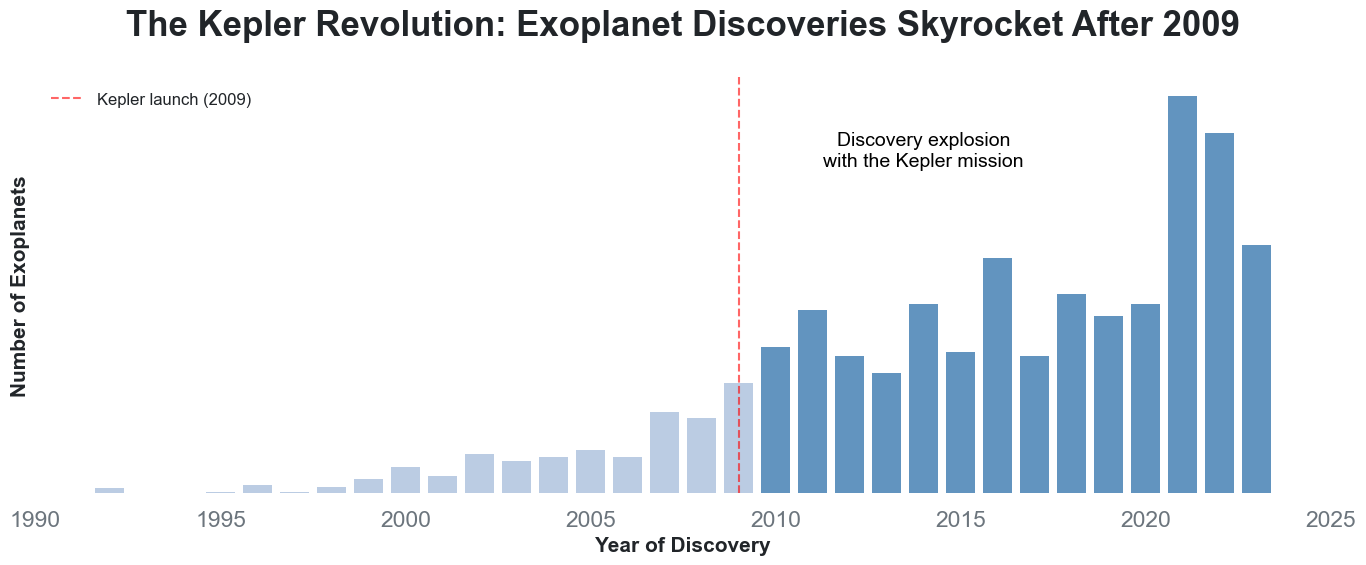

In [41]:
# On va garder juste les lignes avec une méthode de découverte
df_clean = df.dropna(subset=["discovery_method"])

# Groupe par année
discovery_counts = (
    df_clean
    .groupby("discovery_year")
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(14,6))

# Barres avec dégradé de couleur (plus foncé après 2010 pour montrer le pic)
colors = ['lightsteelblue' if year < 2010 else 'steelblue' for year in discovery_counts["discovery_year"]]

plt.bar(
    discovery_counts["discovery_year"],
    discovery_counts["count"],
    width=0.8,
    color=colors,
    edgecolor='none',
    alpha=0.85
)

# Ajoute une ligne verticale pour marquer le début de Kepler
plt.axvline(x=2009, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='Kepler launch (2009)')

# Ajoute un commentaire au niveau du pic
plt.text(2014, 250,
         'Discovery explosion\nwith the Kepler mission',
         fontsize=14, color='black', ha='center', va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))

plt.xlabel("Year of Discovery", fontsize=15, fontweight='bold')
plt.ylabel("Number of Exoplanets", fontsize=15, fontweight='bold')
plt.title("The Kepler Revolution: Exoplanet Discoveries Skyrocket After 2009",
          fontsize=25, fontweight='bold', pad=30)

plt.ylim(bottom=0)
plt.xlim(1990, 2025)

plt.grid(False)

plt.yticks([])

# Supprime tous les cadres
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.legend(loc='upper left', fontsize=12, frameon=False)
plt.tight_layout()
plt.show()

On remarque qu'il y a une augmentation après 2009 qui est dû au lancement du telescope Kepler. On a des pics en 2016 et 2014 qui sont dû à la publication de la récolte de données collecté par Kepler. C'est pour ça qu'on a une évolution progressive.

Choix du graphique :
J'ai choisi de mettre en avant le lancement de Kepler donc mettre un highlight sur les années qui suivent 2009.

On pourrait faire un stacked mais j'ai testé et c'est assez moche comme ya deux classes majoritaires et les autres sont vraiment minimes (A éviter je pense).

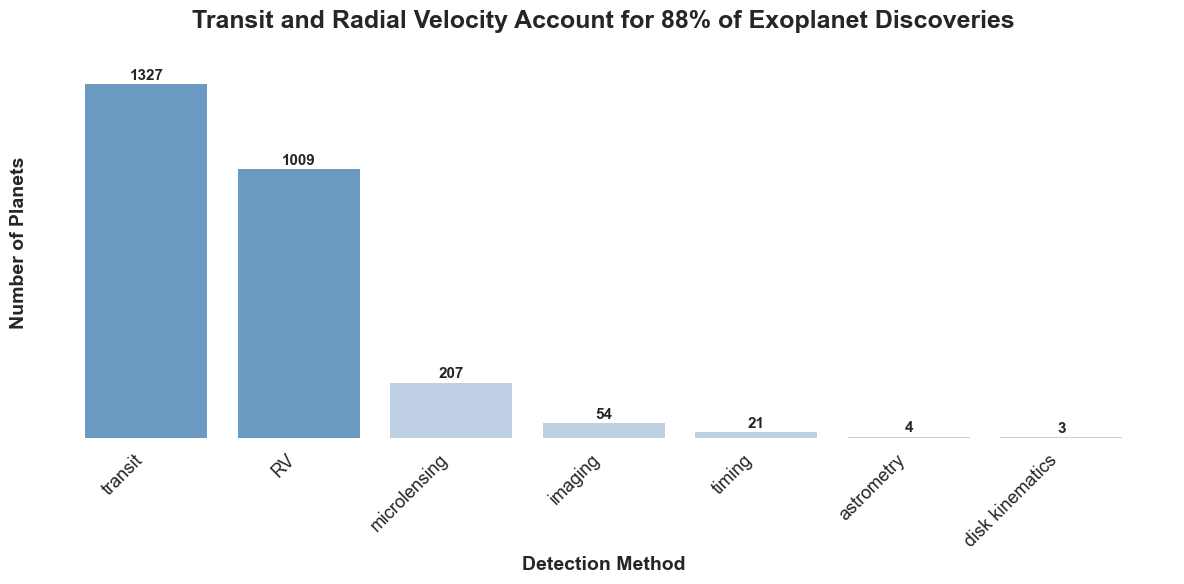

In [35]:
import matplotlib.pyplot as plt

method_counts = df['discovery_method'].value_counts()

# Défini les couleurs
def get_color(method):
    method_lower = str(method).lower()
    if 'transit' in method_lower or 'rv' in method_lower or 'radial' in method_lower:
        return 'steelblue'
    return 'lightsteelblue'

colors = [get_color(m) for m in method_counts.index]

plt.figure(figsize=(12,6))

# Crée le graphique à barres sans les bordure
bars = plt.bar(method_counts.index,
               method_counts.values,
               color=colors,
               edgecolor='none',
               alpha=0.8)

# Ajoute les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Detection Method', fontsize=14, fontweight='bold')
plt.ylabel('Number of Planets', fontsize=14, fontweight='bold')

plt.title('Transit and Radial Velocity Account for 88% of Exoplanet Discoveries',
          fontsize=18, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=13)

plt.grid(False)

plt.yticks([])

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.ylim(0, max(method_counts.values) * 1.1)

plt.tight_layout()
plt.show()

Les deux méthodes de détection principales sont le transit et le rv avec respectivement 1139 et 1010 planètes découvertes.

Transit
- Mesure la baisse périodique de luminosité d'une étoile quand une planète passe devant elle
- Permet de déterminer la taille de la planète et sa période orbitale

Vélocité radiale (rv)
- Détecte les petites oscillations d'une étoile causées par l'attraction gravitationnelle d'une planète en orbite
- Permet de mesurer la masse minimale de la planète et sa période

Imaging
- Consiste à prendre une photo directe de la planète en masquant la lumière aveuglante de son étoile
- Utile pour les planètes jeunes, massives et très éloignées de leur étoile

Timing
- Observe les variations régulières dans le signal d'un pulsar ou d'une étoile binaire pour déduire la présence d'une planète
- Très sensible mais ne fonctionne que pour des systèmes stellaires très particuliers

Microlensing
- Observe l'effet de lentille gravitationnelle quand une étoile passe devant une autre, amplifiant sa lumière.
- Une planète autour de l'étoile "lentille" crée un pic supplémentaire dans la courbe de luminosité.

Astrometry
- Mesure avec une extrême précision les petits déplacements d'une étoile sur le ciel
- Permet de déterminer la masse réelle et l'orbite complète de la planète

Disk Kinematics
- Observe les perturbations dans la rotation d'un disque de poussière autour d'une jeune étoile.
- La présence d'une planète crée des ondulations ou des lacunes dans le disque.

Il semblerait qu'il n'y a pas de découverte avec disk kinemetics. En effet, on a

Choix du graphique :
J'ai enlevé la grid et la barre des ordonnées, indiqué les chiffres directement sur les barres et mis en highlight le résultat qu'on cherche à faire ressortir. Le titre est parlant et plus indicateur.

Comme vu dans le cours, l'objectif c'est pas de donner des résultats quelconque mais de faire ressortir des observations.

In [119]:
disk_kinematics_count = df[df['discovery_method'] == 'disk kinematics'].shape[0]
print(f"Planètes détectées par Disk Kinematics : {disk_kinematics_count}")

Planètes détectées par Disk Kinematics : 0


## Semi major axis (AU)

C:\Users\Nbayo\AppData\Local\Temp\ipykernel_18772\1627671359.py:27: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.scatterplot(


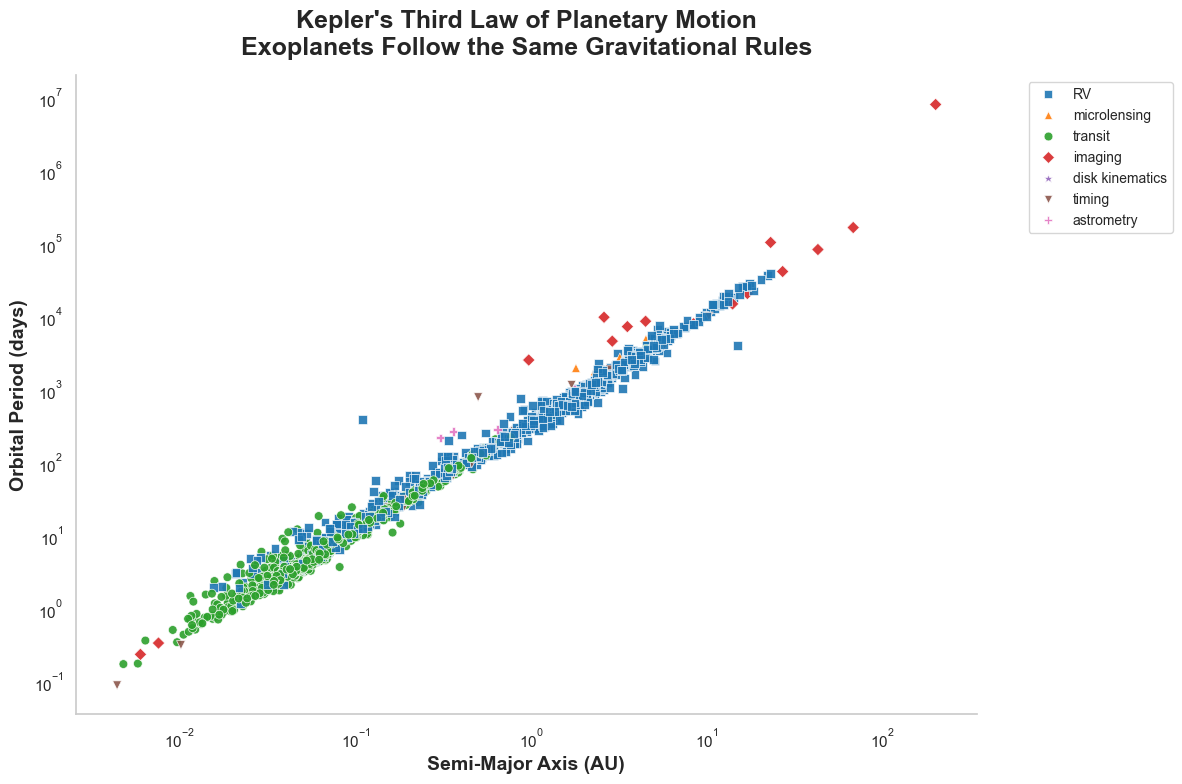

In [42]:
plt.figure(figsize=(12,8))

unique_methods = df["discovery_method"].unique()

# Mapping formes
markers = {
    "transit": "o",
    "rv": "s",
    "RV": "s",  # Ajout pour la casse majuscule
    "radial velocity": "s",
    "imaging": "D",
    "microlensing": "^",
    "timing": "v",
    "astrometry": "P",
    "disk kinematics": "*",
    "Disk Kinematics": "*",  # Au cas où
}

# Palette avec du contraste
palette = sns.color_palette("tab10", n_colors=len(unique_methods))

sns.scatterplot(
    data=df,
    x="semi_major_axis",
    y="period",
    hue="discovery_method",
    style="discovery_method",
    markers=markers,
    palette=palette,
    alpha=0.9,
    s=40
)


plt.xscale("log")
plt.yscale("log")

plt.xlabel("Semi-Major Axis (AU)", fontsize=14, fontweight='bold')
plt.ylabel("Orbital Period (days)", fontsize=14, fontweight='bold')
plt.title("Kepler's Third Law of Planetary Motion\nExoplanets Follow the Same Gravitational Rules",
          fontsize=18, fontweight='bold', pad=15)

plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.tick_params(axis='both', which='major', labelsize=11)

plt.legend(bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()
plt.show()

La plupart des planetes proche de leur étoile hote ont été découverte aevc la méthode transit alors que pour celle qui sont plus éloigné ils ont eu recourt à la méthode vr.

La troisieme loi de kepler stipule que le carré de la période orbitale d'une planète est proportionnel au cube du demi-grand axe de son orbite. Du coup en appliquant une transformation logarithmique on devrait obtenir une ligne droite. C'est exactement ce qu'on observe.

Ce graph est très important car de base les lois de Kepler sont basées sur le fonctionnement de notre système solaire. Ce résultat montre qu'elles sont également applicables dans d'autres systemes.

https://astroryan97.medium.com/analyzing-exo-planet-data-92b15b28da29

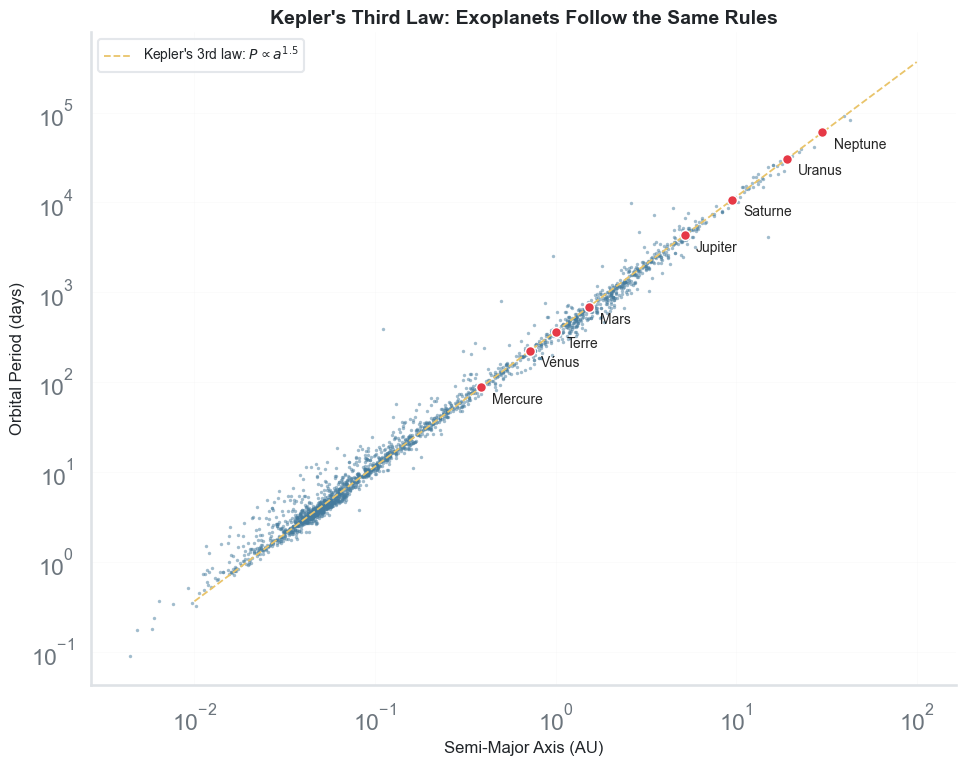

In [39]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

if 'period' in df.columns and 'semi_major_axis' in df.columns:
    sub = df.dropna(subset=['period', 'semi_major_axis'])
    sub = sub[(sub['period'] > 0) & (sub['semi_major_axis'] > 0)]
    sub = sub[sub['period'] < 100000]

    plt.scatter(sub['semi_major_axis'], sub['period'],
                s=6, alpha=0.5, color='#457B9D', linewidths=0)

    # Loi de Kepler
    a_ref = np.logspace(-2, 2, 200)
    plt.plot(a_ref, 365.25 * a_ref**1.5, color='#E9C46A',
             lw=1.3, ls='--', label='Kepler\'s 3rd law: $P \\propto a^{1.5}$')

    # Planètes du Système Solaire
    solar_system = [
        ('Mercure', 0.387, 88),
        ('Vénus', 0.723, 225),
        ('Terre', 1.0, 365),
        ('Mars', 1.524, 687),
        ('Jupiter', 5.203, 4333),
        ('Saturne', 9.537, 10759),
        ('Uranus', 19.191, 30687),
        ('Neptune', 30.069, 60190)
    ]

    for name, a, p in solar_system:
        plt.scatter(a, p, s=50, color='#E63946', edgecolor='white', linewidth=1, zorder=5)
        plt.annotate(name, (a, p), fontsize=10, color='black', alpha=0.85,
                     xytext=(8, -4), textcoords='offset points', ha='left', va='top')

    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel("Semi-Major Axis (AU)", fontsize=12)
    plt.ylabel("Orbital Period (days)", fontsize=12)
    plt.title("Kepler's Third Law: Exoplanets Follow the Same Rules", fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

else:
    print(" Colonnes 'period' ou 'semi_major_axis' absentes")

plt.tight_layout()
plt.show()

C'est le meme graph mais avec les planetes de notre systeme en reference. On pourra utiliser l'autre pour parler des biais de detection.

In [76]:
df["discovery_method"] = df["discovery_method"].str.lower().str.strip()

# On enlève les valeurs aberrantes ou nulles
df = df[
    (df["semi_major_axis"] > 0) &
    (df["period"] > 0) &
    (df["mass"] > 0)
]

# Eccentricité
df["eccentricity"] = df["eccentricity"].fillna(0)

In [45]:
print(df['mass'].describe())

count    2634.000000
mean        2.124582
std         6.857034
min         0.000008
25%         0.028300
50%         0.465000
75%         1.920000
max       263.000000
Name: mass, dtype: float64


C:\Users\Nbayo\AppData\Local\Temp\ipykernel_18772\257044576.py:7: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.scatterplot(


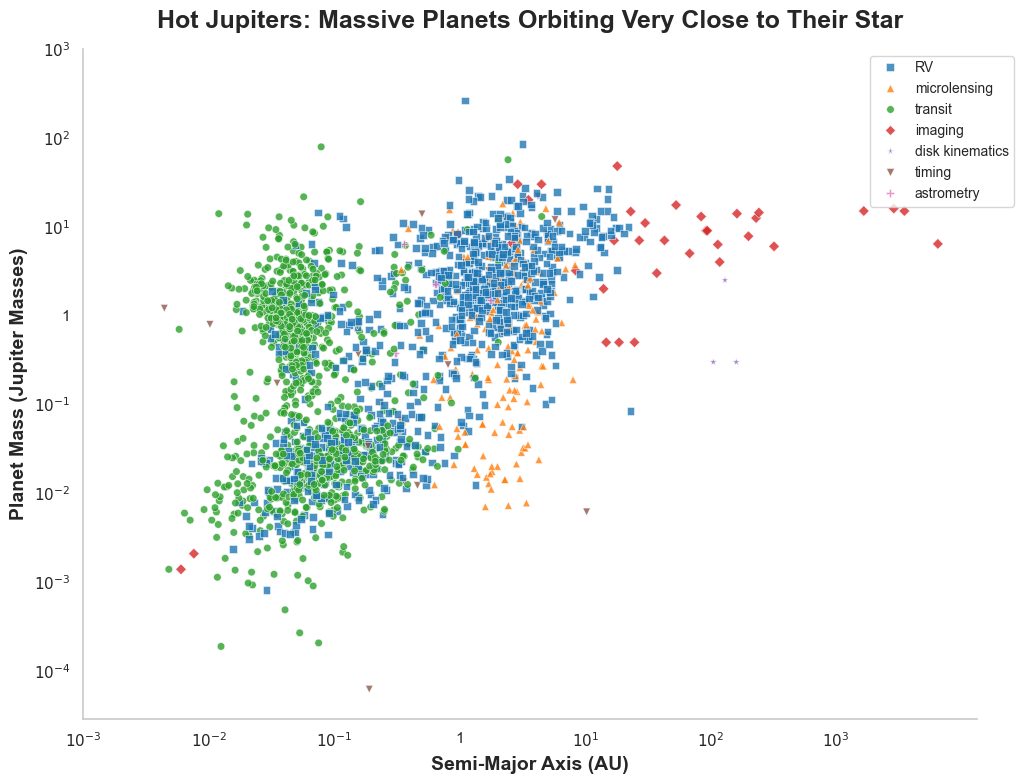

In [59]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="semi_major_axis",
    y="mass",
    hue="discovery_method",
    style="discovery_method",
    markers=markers,
    palette=palette,
    alpha=0.8,
    s=30
)

plt.xscale("log")
plt.yscale("log")

ax = plt.gca()

ax.set_xticks([0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_xticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

ax.set_yticks([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_yticklabels([r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

plt.xlabel("Semi-Major Axis (AU)", fontsize=14, fontweight='bold')
plt.ylabel("Planet Mass (Jupiter Masses)", fontsize=14, fontweight='bold')
plt.title("Hot Jupiters: Massive Planets Orbiting Very Close to Their Star",
          fontsize=18, fontweight='bold', pad=15)

plt.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.legend(bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()
plt.show()

Il existe un type de planetes très similaire à Jupiter dont l orbit est très proche de leur étoile hote. On les appelle les Hot Jupiter. Elles ont été découvertes assez rapidement car elles font partie des planetes les plus facilement détectable avec la méthode rv. C est dû fait qu elle sont plus grosse donc provoquent des perturbations plus importantes de leur étoile hote (plus gros effet Doppler).

https://www.sciencedirect.com/topics/physics-and-astronomy/hot-jupiters

(Je vais améliorer le graph pour indiquer où sont précisémenent les hot jupiter)

## Orbital period (days)

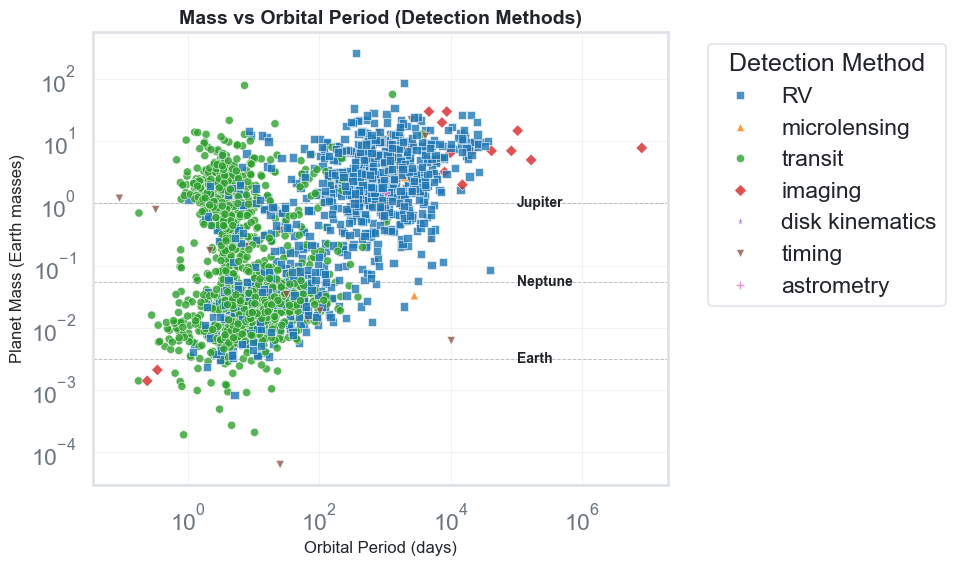

In [40]:
plt.figure(figsize=(10,6))

markers = {
    "transit": "o",
    "rv": "s",
    "RV": "s",
    "disk kinematics": "*",
    "radial velocity": "s",
    "imaging": "D",
    "microlensing": "^",
    "timing": "v",
    "astrometry": "P"
}

# Palette de couleurs
methods = df['discovery_method'].unique()
palette = dict(zip(methods, sns.color_palette("tab10", n_colors=len(methods))))

# Scatter plot unique avec hue et style
sns.scatterplot(
    data=df,
    x="period",
    y="mass",
    hue="discovery_method",
    style="discovery_method",
    markers=markers,
    palette=palette,
    alpha=0.8,
    s=35
)

# planetes de reference
solar_refs = df[df["name"].isin(["Earth", "Jupiter", "Neptune"])]
for _, row in solar_refs.iterrows():
    # ligne horizontale de repère
    plt.axhline(row["mass"], color="#8b949e", linewidth=0.7, linestyle="--", alpha=0.6)
    # texte à droite
    plt.text(1e5, row["mass"], row["name"], fontsize=10, fontweight="bold",
             va="center", ha="left")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Orbital Period (days)", fontsize=12)
plt.ylabel("Planet Mass (Earth masses)", fontsize=12)
plt.title("Mass vs Orbital Period (Detection Methods)", fontsize=14, fontweight='bold')

plt.legend(title="Detection Method", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Masse de l'étoile par rapport à la distance

Températures : min=58K, max=8500K


C:\Users\Nbayo\AppData\Local\Temp\ipykernel_18772\1746576259.py:66: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  plt.tight_layout()


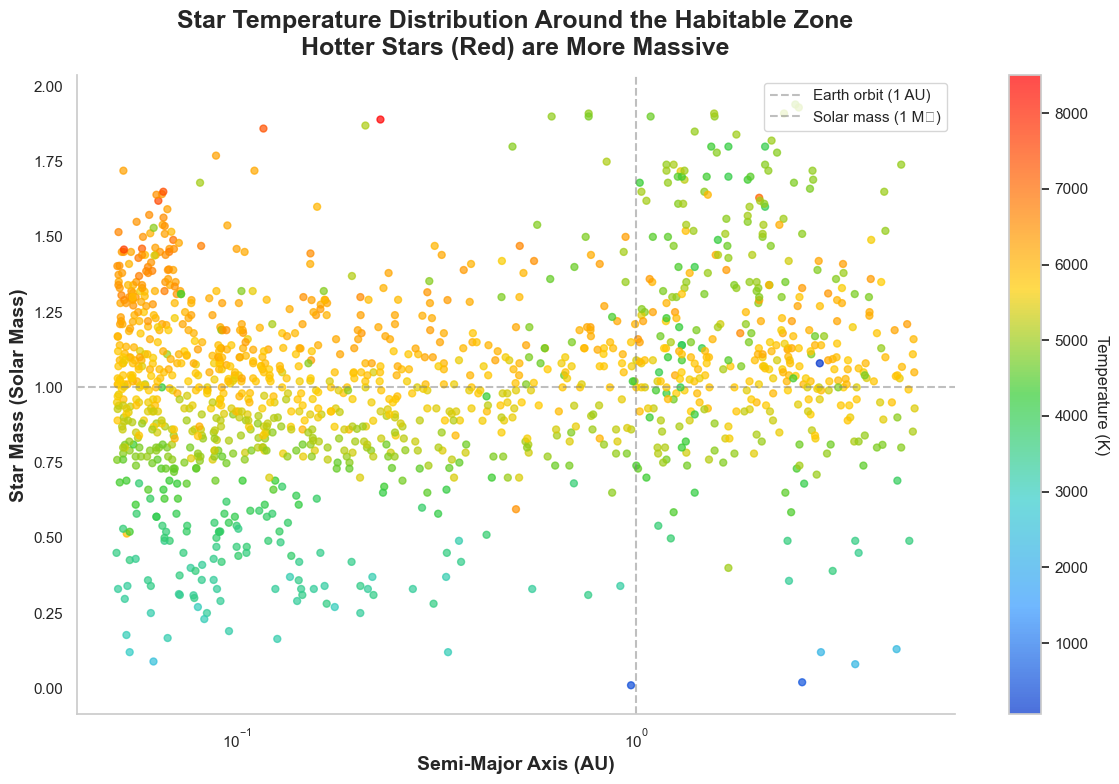

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(12,8))

df_hz = df[
    (df["semi_major_axis"] < 5) &
    (df["host_star_mass"] < 2) &
    (df["semi_major_axis"] > 0.05) &
    (df["host_star_temp"] < 15000)
]

t_min = df_hz["host_star_temp"].min()
t_max = df_hz["host_star_temp"].max()

print(f"Températures : min={t_min:.0f}K, max={t_max:.0f}K")

progressive_cmap = LinearSegmentedColormap.from_list(
    "progressive_temp",
    [
        "#0033cc",   # bleu foncé
        "#3399ff",   # bleu clair
        "#33cccc",   # cyan
        "#33cc33",   # vert
        "#ffcc00",   # jaune
        "#ff6600",   # orange
        "#ff0000"    # rouge
    ]
)

sc = plt.scatter(
    df_hz["semi_major_axis"],
    df_hz["host_star_mass"],
    c=df_hz["host_star_temp"],
    cmap=progressive_cmap,
    alpha=0.7,
    s=25
)

cbar = plt.colorbar(sc, label="Star Temperature (K)")
cbar.ax.set_ylabel("Temperature (K)", rotation=270, labelpad=15)

plt.xscale("log")
plt.xlabel("Semi-Major Axis (AU)", fontsize=14, fontweight='bold')
plt.ylabel("Star Mass (Solar Mass)", fontsize=14, fontweight='bold')
plt.title("Star Temperature Distribution Around the Habitable Zone\nHotter Stars (Red) are More Massive",
          fontsize=18, fontweight='bold', pad=15)

plt.axvline(x=1, linestyle="--", color="gray", alpha=0.5, linewidth=1.5, label="Earth orbit (1 AU)")
plt.axhline(y=1, linestyle="--", color="gray", alpha=0.5, linewidth=1.5, label="Solar mass (1 M☉)")

plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.legend(loc="upper right", fontsize=11)
plt.tight_layout()
plt.show()

Choix du graphique :
J'ai utilisé une barre de couleur avec un shift linéaire comme il l'a dit dans le cours.

Le semi-major axis c'est la distance moyenne entre la planete et son étoile.

## Masse et radius

C:\Users\Nbayo\AppData\Local\Temp\ipykernel_16000\1148369965.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


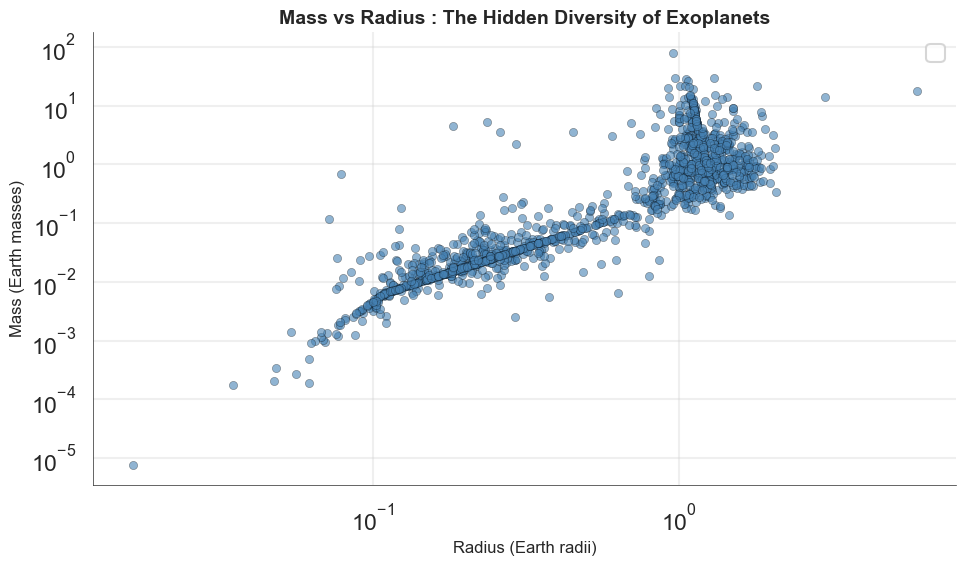

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

sns.scatterplot(
    data=df,
    x="radius",
    y="mass",
    alpha=0.6,
    s=35,
    color='steelblue',
    edgecolors='black',
    linewidth=0.3
)

# Régression linéaire sur les logs
df_clean = df.dropna(subset=["radius", "mass"])
df_clean = df_clean[(df_clean["radius"] > 0) & (df_clean["mass"] > 0)]

x_log = np.log10(df_clean["radius"])
y_log = np.log10(df_clean["mass"])

slope, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Radius (Earth radii)", fontsize=12)
plt.ylabel("Mass (Earth masses)", fontsize=12)
plt.title("Mass vs Radius : The Hidden Diversity of Exoplanets", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

plt.tight_layout()
plt.show()

On observe une relation croissante entre le rayon et la mass. Globalement, plus une planète est grande, plus elle est massive. A gauche, on a surement les planetes rocheuses et à droite les planetes gazeuses (Je rentre plus en détail sur ça dans le notebook clustering).la masse varie pas mal pour un même rayon (géantes gazeuses). Ca montre que pour les grandes planetes ajouter de la masse change pas beaucoup le rayon.

Il existe beaucoup d'articles sur cette relation masse-radius.

Ya cet article qui est pas mal qui en parle. J'ai fait mon clustering dans l'autre notebookn en me basant sur ça
https://academic.oup.com/mnras/article/525/3/3469/7246902

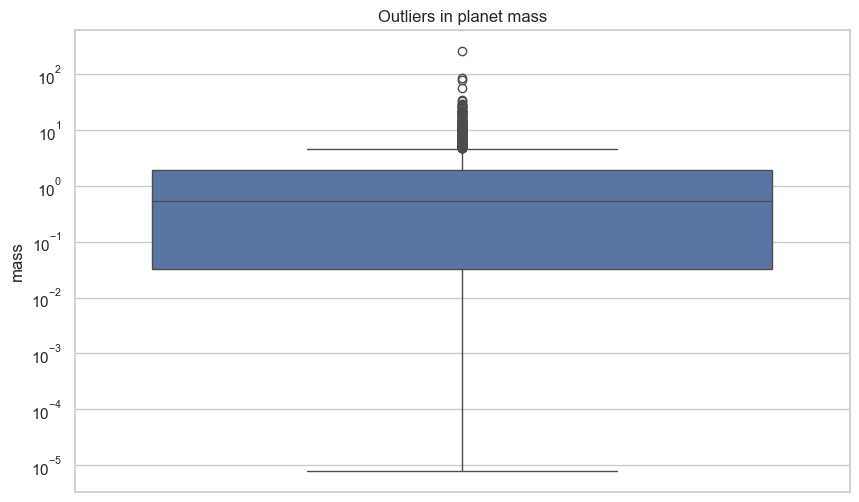

In [183]:
plt.figure()

sns.boxplot(
    y=df['mass']
)

plt.yscale("log")

plt.title(
    "Outliers in planet mass"
)

plt.show()

Faudra gérer les outliers pour le clustering

C:\Users\Nbayo\AppData\Local\Temp\ipykernel_18772\1490598164.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['mass_jupiter'] = sub['mass'] / 318


Points bleus (transit): 1111
Points oranges (RV): 957
Points gris (autres): 52


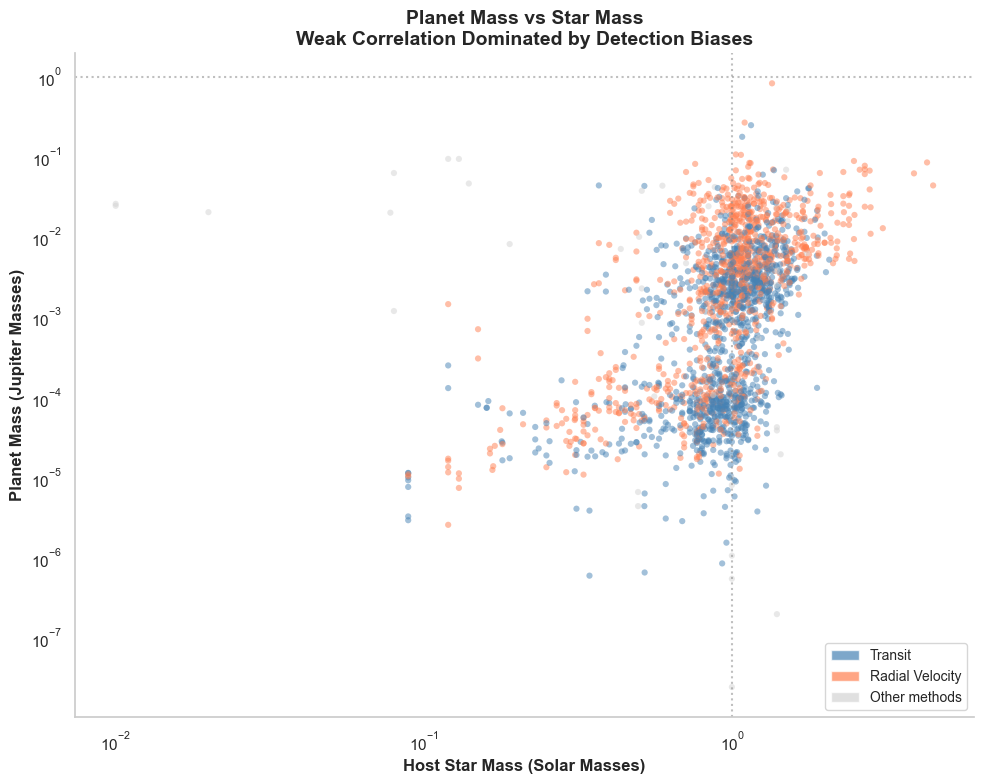

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# on filtre les données
mask = df['mass'].notna() & df['host_star_mass'].notna() & (df['mass'] > 0) & (df['host_star_mass'] > 0)
sub = df[mask]

# Convertir en masses de Jupiter
sub['mass_jupiter'] = sub['mass'] / 318

# Fonction de couleur robuste
def get_color(method):
    if method is None:
        return 'lightgray'
    method_str = str(method).lower()
    if 'transit' in method_str:
        return 'steelblue'
    elif 'radial' in method_str or method_str == 'rv':
        return 'coral'
    else:
        return 'lightgray'

colors = sub['discovery_method'].map(get_color)

# Compter pour vérifier
print(f"Points bleus (transit): {sum(c == 'steelblue' for c in colors)}")
print(f"Points oranges (RV): {sum(c == 'coral' for c in colors)}")
print(f"Points gris (autres): {sum(c == 'lightgray' for c in colors)}")

plt.figure(figsize=(10, 8))

plt.scatter(sub['host_star_mass'], sub['mass_jupiter'], c=colors, alpha=0.5, s=20, edgecolors='none')

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Host Star Mass (Solar Masses)", fontsize=12, fontweight='bold')
plt.ylabel("Planet Mass (Jupiter Masses)", fontsize=12, fontweight='bold')
plt.title("Planet Mass vs Star Mass\nWeak Correlation Dominated by Detection Biases",
          fontsize=14, fontweight='bold')

plt.axhline(y=1, linestyle=':', color='gray', alpha=0.5, label='Jupiter mass (1 MJ)')
plt.axvline(x=1, linestyle=':', color='gray', alpha=0.5, label='Solar mass (1 M☉)')

legend_elements = [
    Patch(facecolor='steelblue', alpha=0.7, label='Transit'),
    Patch(facecolor='coral', alpha=0.7, label='Radial Velocity'),
    Patch(facecolor='lightgray', alpha=0.7, label='Other methods')
]

plt.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

On remarque que la distribution des masses stellaires dans notre échantillon montre un pic autour d'une masse solaire. C'est pas un reflet de la réalité astrophysique (du genre les naines sont bien plus nombreuses dans la galaxie), mais c'est plutot un biais observationnel parce que les télescopes et les méthodes de détection ont été optimisés pour les étoiles de type solaire.

(A la fin faudra uniformiser les couleurs qu'on utilise pour la cohérence)

C:\Users\Nbayo\AppData\Local\Temp\ipykernel_18772\1533167951.py:44: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  plt.tight_layout()


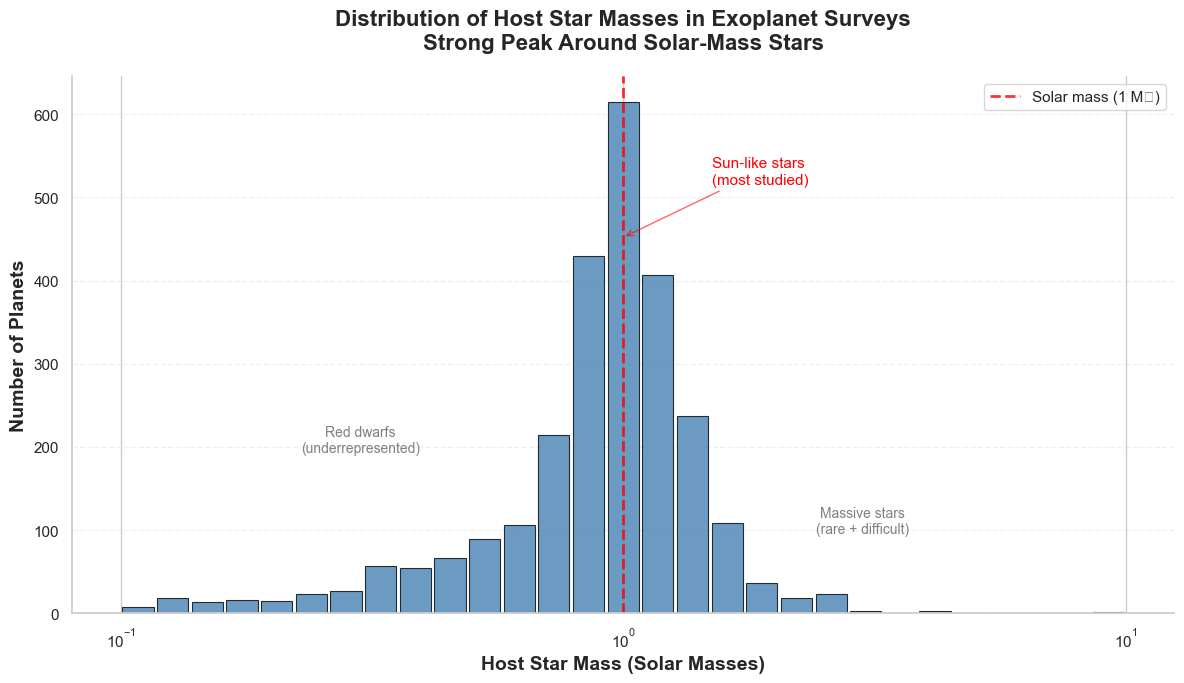

In [73]:
star_masses = df['host_star_mass'].dropna()
star_masses = star_masses[(star_masses > 0) & (star_masses < 10)]  # on enleve les extrêmes

plt.figure(figsize=(12, 7))

# Bins logarithmiques
bins_log = np.logspace(np.log10(0.1), np.log10(10), 30)

plt.hist(star_masses, bins=bins_log, color='steelblue', alpha=0.8,
         edgecolor='black', linewidth=0.8, rwidth=0.9)

plt.xscale('log')
plt.xlabel("Host Star Mass (Solar Masses)", fontsize=14, fontweight='bold')
plt.ylabel("Number of Planets", fontsize=14, fontweight='bold')
plt.title("Distribution of Host Star Masses in Exoplanet Surveys\nStrong Peak Around Solar-Mass Stars",
          fontsize=16, fontweight='bold', pad=20)

# Ajouter une ligne verticale pour le Soleil
plt.axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Solar mass (1 M☉)')

# Annotations
plt.annotate('Sun-like stars\n(most studied)', xy=(1, plt.ylim()[1]*0.7),
             xytext=(1.5, plt.ylim()[1]*0.8), fontsize=11, color='red',
             arrowprops=dict(arrowstyle='->', color='red', alpha=0.6))

plt.annotate('Red dwarfs\n(underrepresented)', xy=(0.3, plt.ylim()[1]*0.3),
             fontsize=10, color='gray', ha='center')

plt.annotate('Massive stars\n(rare + difficult)', xy=(3, plt.ylim()[1]*0.15),
             fontsize=10, color='gray', ha='center')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(loc='upper right', fontsize=11)

# Supprime les cadres du haut et droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Il y a clairement un biais de détection

## A revoir

C'est juste des idées si on veut ajouter des graphs 3D

In [80]:
import plotly.express as px
import numpy as np

df_plot = df.dropna(subset=[
    "semi_major_axis", "period", "eccentricity", "mass", "radius"
]).copy()

# Filtrage initial large
df_plot = df_plot[
    (df_plot["semi_major_axis"] < 50) &
    (df_plot["mass"] < 10000)
]

# Filtrage par percentiles (on garde 98% des données)
period_upper = df_plot["period"].quantile(0.98)
ecc_upper = df_plot["eccentricity"].quantile(0.98)
mass_upper = df_plot["mass"].quantile(0.98)
sma_upper = df_plot["semi_major_axis"].quantile(0.98)

df_plot = df_plot[
    (df_plot["period"] < period_upper) &
    (df_plot["eccentricity"] < ecc_upper) &
    (df_plot["mass"] < mass_upper) &
    (df_plot["semi_major_axis"] < sma_upper) &
    (df_plot["semi_major_axis"] > 0.05)
]

print(f"Nombre de points après filtrage : {len(df_plot)}")
print(f"Période max: {df_plot['period'].max():.0f} jours")
print(f"Excentricité max: {df_plot['eccentricity'].max():.2f}")

df_plot["size"] = np.log1p(df_plot["radius"])

fig = px.scatter_3d(
    df_plot,
    x="semi_major_axis",
    y="period",
    z="eccentricity",
    color="mass",
    size="size",
    color_continuous_scale="viridis",
    log_x=True,
    log_y=True,
    opacity=0.7,
    hover_name="name",
    title="Orbital Architecture of Exoplanets (98th Percentile Filtered)",
    labels={
        "semi_major_axis": "Distance (AU)",
        "period": "Orbital Period (days)",
        "eccentricity": "Eccentricity",
        "mass": "Planet Mass (Earth masses)"
    }
)

fig.update_layout(
    scene=dict(
        xaxis=dict(showspikes=False),
        yaxis=dict(showspikes=False),
        zaxis=dict(showspikes=False)
    ),
    template="plotly_white"
)

fig.show()

Nombre de points après filtrage : 680
Période max: 14774 jours
Excentricité max: 0.54


C'est assez plat mais c'est parce qu'il faudrait voir la troisieme dimension qu'on veut ajouter pour que ça ait du sens. Je vais regarder ça plus tard.

In [81]:
import plotly.express as px
import numpy as np

df_plot = df.copy()
df_plot = df_plot.dropna(subset=["mass", "host_star_mass", "period", "discovery_method"])
df_plot["discovery_method"] = df_plot["discovery_method"].str.lower().str.strip()

# Limite les extrêmes
df_plot = df_plot[
    (df_plot["mass"] < 5000) &
    (df_plot["host_star_mass"] < 5)
]

df_plot["size"] = np.log1p(df_plot["period"])

# Scatter interactif
fig = px.scatter(
    df_plot,
    x="host_star_mass",
    y="mass",
    color="discovery_method",
    size="size",
    size_max=18,
    log_x=True,
    log_y=True,
    hover_name="name",
    hover_data={
        "host_star_mass": ":.2f",
        "mass": ":.2f",
        "period": ":.1f",
        "semi_major_axis": ":.2f",
        "discovery_method": True
    },
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="Planet Mass vs Host Star Mass",
    labels={
        "host_star_mass": "Star Mass (Solar Masses)",
        "mass": "Planet Mass (Earth Masses)"
    },
    opacity=0.75
)

fig.add_hline(
    y=1,
    line_dash="dash",
    line_color="gray",
    annotation_text="Earth",
    annotation_position="top left"
)

fig.add_hline(
    y=318,
    line_dash="dot",
    line_color="gray",
    annotation_text="Jupiter",
    annotation_position="top left"
)

fig.add_vline(
    x=1,
    line_dash="dash",
    line_color="gray",
    annotation_text="Sun",
    annotation_position="top right"
)

fig.update_traces(
    marker=dict(
        line=dict(width=0.5, color="black")  # contour léger
    )
)

fig.update_layout(
    template="plotly_white",
    hovermode="closest",
    legend_title="Detection Method",
    title_x=0.5,
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show()

Ca c'est une version en 2D par méthode de transit. Encore une fois, il va falloir l'améliorer parce que j'aime pas trop les couleurs

In [82]:
import plotly.express as px
import numpy as np

# Sélection des colonnes nécessaires
required_cols = ["semi_major_axis", "period", "eccentricity", "mass", "radius", "name"]
df_plot = df[required_cols].dropna()

# Filtrage
df_plot = df_plot[
    (df_plot["semi_major_axis"] < 50) &
    (df_plot["mass"] < 10000) &
    (df_plot["radius"] > 0) &
    (df_plot["period"] > 0) &
    (df_plot["eccentricity"] >= 0)
]

# Percentiles
period_upper = df_plot["period"].quantile(0.98)
ecc_upper = df_plot["eccentricity"].quantile(0.98)
mass_upper = df_plot["mass"].quantile(0.98)
sma_upper = df_plot["semi_major_axis"].quantile(0.98)

df_plot = df_plot[
    (df_plot["period"] < period_upper) &
    (df_plot["eccentricity"] < ecc_upper) &
    (df_plot["mass"] < mass_upper) &
    (df_plot["semi_major_axis"] < sma_upper) &
    (df_plot["semi_major_axis"] > 0.05)
]

print(f" {len(df_plot)} points après filtrage")

# Taille basée sur le rayon (échelle log)
df_plot["size"] = np.log1p(df_plot["radius"])

fig = px.scatter_3d(
    df_plot,
    x="semi_major_axis",
    y="period",
    z="eccentricity",
    color="mass",
    size="size",
    color_continuous_scale="Viridis",
    log_x=True,
    log_y=True,
    opacity=0.7,
    hover_name="name",
    title="Orbital Architecture of Exoplanets",
    labels={
        "semi_major_axis": "Distance (AU)",
        "period": "Orbital Period (days)",
        "eccentricity": "Eccentricity",
        "mass": "Planet Mass (M_Earth)"
    }
)

fig.update_layout(
    scene=dict(
        xaxis_title="Distance (AU)",
        yaxis_title="Orbital Period (days)",
        zaxis_title="Eccentricity",
        xaxis_type="log",
        yaxis_type="log"
    ),
    template="plotly_white",
    title_x=0.5
)

fig.show()

 680 points après filtrage


In [83]:
import plotly.express as px
import numpy as np

# Nettoyage
df_plot = df.copy()
df_plot = df_plot.dropna(subset=["mass", "host_star_mass", "period", "host_star_temp"])

# Filtrage par valeurs fixes
df_plot = df_plot[
    (df_plot["mass"] < 2000) &
    (df_plot["mass"] > 0.05) &
    (df_plot["host_star_mass"] < 3) &
    (df_plot["host_star_mass"] > 0.1) &
    (df_plot["host_star_temp"] < 10000) &
    (df_plot["host_star_temp"] > 2000)
]

print(f"Points après filtrage: {len(df_plot)}")

# Taille = période
df_plot["size"] = np.log1p(df_plot["period"])

fig = px.scatter(
    df_plot,
    x="host_star_mass",
    y="mass",
    size="size",
    color="host_star_temp",
    color_continuous_scale="RdBu_r",
    size_max=18,
    log_x=True,
    log_y=True,
    hover_name="name",
    hover_data={
        "host_star_mass": ":.2f",
        "mass": ":.2f",
        "period": ":.1f",
        "semi_major_axis": ":.2f",
        "host_star_temp": ":.0f"
    },
    title="Planet Mass vs Host Star Mass (Outliers Removed)",
    labels={
        "host_star_mass": "Star Mass (Solar Masses)",
        "mass": "Planet Mass (Earth Masses)",
        "host_star_temp": "Star Temperature (K)"
    },
    opacity=0.75
)

# Lignes de référence
fig.add_hline(y=1, line_dash="dash", line_color="gray",
              annotation_text="Earth", annotation_position="top left")

fig.add_hline(y=318, line_dash="dot", line_color="gray",
              annotation_text="Jupiter", annotation_position="top left")

fig.add_vline(x=1, line_dash="dash", line_color="gray",
              annotation_text="Sun", annotation_position="top right")

# Style
fig.update_traces(
    marker=dict(line=dict(width=0.5, color="black"))
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show()

Points après filtrage: 1396


Ca c'est en fonction de la température mais va falloir changer dans tous les cas l'échelle de température parce que j'ai pas utilisé un shift linéaire. Là c'est divergent comme ya du clair au milieu et on peut l'utiliser que pour des résultats binaires du type perte/gain, chaud/froid etc. Ici tout est relativement chaud donc vaut mieux éviter.

In [84]:
import plotly.express as px
import numpy as np

df_plot = df.copy()
df_plot = df_plot.dropna(subset=[
    "mass", "host_star_mass", "period",
    "semi_major_axis", "discovery_method"
])

df_plot["discovery_method"] = df_plot["discovery_method"].str.lower().str.strip()

# Filtrage
df_plot = df_plot[
    (df_plot["mass"] < 5000) &
    (df_plot["host_star_mass"] < 5) &
    (df_plot["semi_major_axis"] < 10)
]

# Taille = log(période)
df_plot["size"] = np.log1p(df_plot["period"])

# Scatter 3D
fig = px.scatter_3d(
    df_plot,
    x="host_star_mass",
    y="mass",
    z="semi_major_axis",
    color="discovery_method",
    size="size",
    size_max=15,
    opacity=0.7,
    hover_name="name",
    hover_data={
        "host_star_mass": ":.2f",
        "mass": ":.2f",
        "period": ":.1f",
        "semi_major_axis": ":.2f",
        "discovery_method": True
    },
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="3D View: Planet Mass, Star Mass and Orbital Distance",
    labels={
        "host_star_mass": "Star Mass (Solar Masses)",
        "mass": "Planet Mass (Earth Masses)",
        "semi_major_axis": "Orbital Distance (AU)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    scene=dict(
        xaxis=dict(type="log", showspikes=False),
        yaxis=dict(type="log", showspikes=False),
        zaxis=dict(type="log", showspikes=False)
    ),
    legend_title="Detection Method",
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

## Piste d'amélioration

- Chercher des articles sur les relations qui existent pour les représenter visuellement
- Faire un clustering en exploitant le radius (ya pas mal d'articles qui le font)
- Faire une map 3D en utilisant les coordonnées des planetes (si possible)
- Faire des graph en exploitant les variables que j'ai pas encore touché